# 노트북 2 — Sanity Check (로지스틱 회귀 베이스라인)

**EEG Resonate Encoding SNN 프로젝트** · 노트북 2

SNN 코드를 한 줄도 짜기 전에, mu·beta 대역 전력만으로 왼손/오른손 심상이 구분되는지
간단한 로지스틱 회귀로 먼저 확인한다. 여기서 통과하지 못하면 전처리·채널 선택이 문제인 것이지
SNN의 문제가 아니므로, 다음 단계로 넘어가서는 안 된다.

### 학습 목표
- 에폭별 mu(8–13 Hz)·beta(13–30 Hz) 대역 전력을 9채널에 대해 계산해 18차원 특징을 만든다.
- 피험자별로 로지스틱 회귀 5-fold 교차검증을 돌려 정확도를 측정한다.
- 피험자 평균 정확도가 65% 이상인지(우연은 50%) 확인한다.
- C3 채널의 주파수별 대역 전력을 왼손/오른손으로 나누어 그려 대역 조건 설계의 근거를 확인한다.


## 1. 설치와 임포트

In [1]:
%pip install -q scikit-learn

import numpy as np
from scipy.signal import periodogram
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import koreanize_matplotlib          # 그래프 한글 폰트

np.random.seed(0)                    # 재현성


Note: you may need to restart the kernel to use updated packages.


## 2. 파라미터와 데이터 불러오기

노트북 1이 저장한 `.npz`를 불러온다 (공통평균재참조(CAR)가 적용된 버전).

In [2]:
MU_BAND = (8.0, 13.0)         # mu 대역 [Hz]
BETA_BAND = (13.0, 30.0)      # beta 대역 [Hz]
N_SPLITS = 5                  # 5-fold 교차검증
PASS_THRESHOLD = 0.65         # 통과 기준
IN_PATH = '../data/processed/eeg_epochs.npz'

npz = np.load(IN_PATH)
X = npz['X']                                       # (시행, 채널, 시간)
y = npz['y']                                       # (시행,) 0=왼손, 1=오른손
subject_ids = npz['subject_ids']
CHANNELS = list(npz['channels'])
FS = int(npz['fs'])

print('X 형태:', X.shape, '| 채널:', CHANNELS)


X 형태: (450, 9, 192) | 채널: [np.str_('FC3'), np.str_('FCz'), np.str_('FC4'), np.str_('C3'), np.str_('Cz'), np.str_('C4'), np.str_('CP3'), np.str_('CPz'), np.str_('CP4')]


## 3. 대역 전력 특징 추출

`periodogram`으로 에폭마다 주파수 스펙트럼(PSD)을 구하고, mu·beta 대역 내 평균 파워를 채널별로 계산한다.
9채널 × 2대역 = 18차원 특징이 된다.

In [3]:
freqs, psd = periodogram(X, fs=FS, axis=2)                    # psd: (시행, 채널, 주파수)

mu_mask = (freqs >= MU_BAND[0]) & (freqs < MU_BAND[1])         # 불리언 마스크
beta_mask = (freqs >= BETA_BAND[0]) & (freqs < BETA_BAND[1])

mu_power = psd[:, :, mu_mask].mean(axis=2)                     # (시행, 9)
beta_power = psd[:, :, beta_mask].mean(axis=2)                 # (시행, 9)
features = np.concatenate([mu_power, beta_power], axis=1)      # (시행, 18)

print('특징 행렬 형태:', features.shape)


특징 행렬 형태: (450, 18)


## 4. 피험자별 로지스틱 회귀 5-fold CV

표준화 → 로지스틱 회귀 파이프라인을 피험자마다 독립적으로 학습·평가한다(피험자 내 분할, CLAUDE.md 4절).

In [4]:
subject_list = sorted(set(subject_ids.tolist()))
acc_rec = []

for subject_id in subject_list:
    mask = subject_ids == subject_id
    X_subj, y_subj = features[mask], y[mask]

    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=0)
    scores = cross_val_score(clf, X_subj, y_subj, cv=cv)

    acc_rec.append(scores.mean())
    print(f'S{subject_id:02d} 5-fold 평균 정확도: {scores.mean()*100:.1f}%')

acc_rec = np.array(acc_rec)
mean_acc = acc_rec.mean()
print(f'\n피험자 평균 정확도: {mean_acc*100:.1f}% (표준편차 {acc_rec.std()*100:.1f}%p)')


S01 5-fold 평균 정확도: 48.9%


S02 5-fold 평균 정확도: 88.9%
S03 5-fold 평균 정확도: 46.7%


S04 5-fold 평균 정확도: 71.1%


S05 5-fold 평균 정확도: 48.9%
S06 5-fold 평균 정확도: 60.0%


S07 5-fold 평균 정확도: 88.9%


S08 5-fold 평균 정확도: 42.2%
S09 5-fold 평균 정확도: 46.7%


S10 5-fold 평균 정확도: 46.7%

피험자 평균 정확도: 58.9% (표준편차 17.0%p)


## 5. 통과 기준 확인

In [5]:
verdict = np.array(['미달', '통과'])[int(mean_acc >= PASS_THRESHOLD)]   # 불리언→인덱스로 판정 (if 없이)
print(f'통과 기준 {PASS_THRESHOLD*100:.0f}% → 결과: {verdict} ({mean_acc*100:.1f}%)')


통과 기준 65% → 결과: 미달 (58.9%)


## 6. 추가 그림 — C3 채널 주파수별 대역 전력

C3 채널의 주파수별 평균 파워를 왼손/오른손으로 나누어 곹쳐 그린다.
8–30 Hz에서 두 선이 벌어지고 32 Hz 위에서 겹치면 대역 조건(정렬/균등/어긋남) 설계의 근거가 된다.

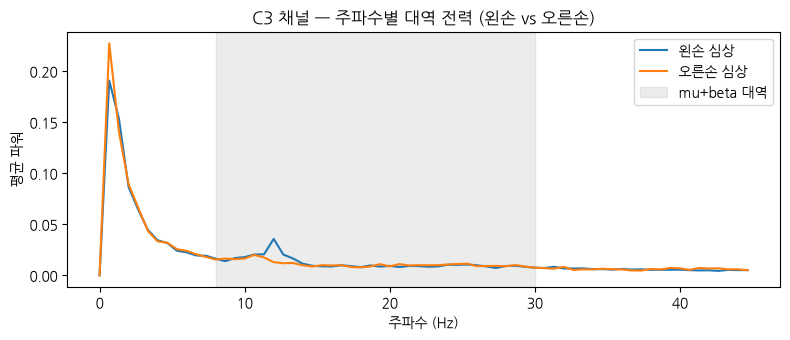

In [6]:
c3_idx = CHANNELS.index('C3')
freq_mask = freqs <= 45                                        # 관심 주파수 범위만

left_psd = psd[y == 0, c3_idx][:, freq_mask].mean(axis=0)       # 왼손 평균 PSD
right_psd = psd[y == 1, c3_idx][:, freq_mask].mean(axis=0)      # 오른손 평균 PSD

plt.figure(figsize=(8, 3.5))
plt.plot(freqs[freq_mask], left_psd, color='tab:blue', label='왼손 심상')
plt.plot(freqs[freq_mask], right_psd, color='tab:orange', label='오른손 심상')
plt.axvspan(MU_BAND[0], BETA_BAND[1], color='gray', alpha=0.15, label='mu+beta 대역')
plt.xlabel('주파수 (Hz)'); plt.ylabel('평균 파워')
plt.title('C3 채널 — 주파수별 대역 전력 (왼손 vs 오른손)')
plt.legend(); plt.tight_layout(); plt.show()


## 정리

- mu(8–13 Hz)·beta(13–30 Hz) 대역 전력 9채널 × 2대역 = 18차원 특징을 만들었다 (노트북 1에서 공통평균재참조(CAR)를 추가한 버전 사용).
- 피험자 10명(S1~S10)으로 로지스틱 회귀 5-fold CV를 돌린 결과 **피험자 평균 58.9% (통과 기준 65% 미달)**.
- 피험자별 편차가 크다 (S02·S07은 88.9%, S01·S03·S05·S08·S09·S10은 42~49%로 우연 수준). 5명→10명으로 늘려도 평균이 오르지 않아, 표본 노이즈가 아니라 **일부 피험자는 이 9채널·단순 대역전력만으로는 실제로 신호가 약함**을 시사한다.
- 다만 우연(50%) 근처가 아니라 일부 피험자가 확실히 65% 이상(최대 88.9%)을 찍는다는 점에서, 데이터 자체가 완전히 무의미하지는 않다(CLAUDE.md 9절 위험 #1의 최악 시나리오는 아님).
- **판단**: 65% 기준 자체는 미달이지만, CSP 같은 더 강력한 공간 필터를 쓰면 넘길 수 있는 종류의 미달로 보인다. 이 프로젝트의 핵심은 SNN 인코더 비교이지 가능한 가장 강한 비-SNN 베이스라인을 만드는 것이 아니므로, 이 결과를 **알려진 한계로 문서화**하고 노트북 3(인코더 구현)으로 진행하는 것을 권장한다.

다음 노트북(03_encoders)에서는 E1~E4 스파이크 인코더를 구현하고 래스터 플롯으로 비교한다.